<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/Capstone_Presentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Overall Purpose of the Python Notebook**

The purpose of this Python notebook is to guide students through a complete data analytics workflow for the Week 13 Capstone Project using the assigned Group 1 customer feedback dataset. The notebook is designed to help students move from raw data to meaningful business insights by organizing the project into clear analytical steps: loading the data, cleaning and preparing it, generating descriptive and inferential statistics, building regression and time-series models, visualizing trends, comparing model performance, and exporting results for reporting and dashboard use. Overall, the notebook supports the course goal of using data-driven decision-making to answer business questions, evaluate performance, and develop actionable recommendations based on evidence.


## **Block 1: Load Data and Inspect Structure**

**Purpose**

The purpose of this code is to import the dataset into Python and perform an initial inspection of its structure. Before any cleaning or analysis begins, it is important to understand what the dataset looks like, what variables it contains, what data types are assigned to each column, and whether any missing values exist.

**Methodology**

This block uses the `pandas` library to read a CSV file from a GitHub link and store it in a DataFrame called `df`. Once the data is loaded, three inspection commands are used:

* `head()` displays the first few rows to preview the dataset
* `info()` shows the number of entries, column names, and data types
* `isna().sum()` counts missing values in each column

This step is part of exploratory data analysis because it helps identify data quality issues before moving into cleaning, statistical analysis, and modeling.

**Simple explanation for students**

This code brings the dataset into Python and checks its overall condition. It lets us see a sample of the data, understand the column types, and identify any missing values that may need to be fixed before analysis.


In [13]:
# Block 1 — Load data and inspect structure

# Import the pandas library, which is used for working with datasets in table form
import pandas as pd

# Store the web address of the CSV file in a variable called file_path
# This dataset is being pulled directly from GitHub
file_path = 'https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/Group1_customer_feedback_data.csv'

# Read the CSV file into a pandas DataFrame called df
# A DataFrame is a table-like structure with rows and columns
df = pd.read_csv(file_path)

# Display the first 5 rows of the dataset
# This gives a quick preview of what the data looks like
print(df.head())

# Display a summary of the dataset structure
# This includes:
# - the total number of rows
# - the names of the columns
# - the number of non-missing values in each column
# - the data type of each column
print(df.info())

# Count the number of missing values in each column
# This helps identify which variables may need cleaning or imputation
print(df.isna().sum())

      Date Region Customer ID  Satisfaction Score  Feedback Length  \
0  1/31/22  North    CUST1000                67.0             35.0   
1  2/28/22   East    CUST1001                74.0            441.0   
2  3/31/22  North    CUST1002                81.0            127.0   
3  4/30/22   West    CUST1003                 NaN            429.0   
4  5/31/22   West    CUST1004                68.0             43.0   

  Issue Resolved  
0            Yes  
1             No  
2            Yes  
3            Yes  
4             No  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                300 non-null    object 
 1   Region              300 non-null    object 
 2   Customer ID         300 non-null    object 
 3   Satisfaction Score  297 non-null    float64
 4   Feedback Length     295 non-null    float64
 5   Issue Resolve

## **Block 2: Clean and Prepare the Data**

**Purpose**

The purpose of this code is to improve the dataset so it is accurate, consistent, and ready for analysis. Raw data often contains issues such as incorrect data types, missing values, or variables that need to be transformed into a more useful format. This block addresses those problems before the student moves on to statistics, modeling, or dashboard creation.

**Methodology**

This code performs several important data preparation steps. First, it converts the `Date` column from text format into a true datetime format so Python can recognize it as a date and use it for sorting, grouping, or time-series analysis. Next, it fills missing values in the numeric columns using median imputation. Then, it creates a new binary variable called `Issue Resolved Flag`, which changes the text responses in the `Issue Resolved` column into numeric values: `1` for Yes and `0` for No. This makes the variable easier to use in statistical and regression models. Finally, the code checks the dataset again to confirm the changes, saves the cleaned dataset as a new CSV file, and prints the first few rows so the user can verify the cleaned output.

**Imputation methods used**

* **Median imputation for `Satisfaction Score`**: Any missing values in `Satisfaction Score` are replaced with the median of that column. This helps preserve the center of the data while reducing the influence of outliers.
* **Median imputation for `Feedback Length`**: Any missing values in `Feedback Length` are replaced with the median of that column. This keeps the dataset complete for later analysis and modeling.
* **No imputation for `Date`**: The `Date` column is converted to datetime format, but missing dates are not filled in this code block.
* **No imputation for `Issue Resolved`**: The code does not fill missing text values in `Issue Resolved`; it only transforms existing Yes/No responses into a binary numeric flag.

**Simple explanation for students**

This code takes the raw dataset and gets it ready for analysis. It fixes the date format, replaces missing numeric values with the median, creates a numeric flag for whether an issue was resolved, checks the cleaned structure, and saves the improved dataset as a new file.


In [14]:
# Block 2 — Clean and prepare the data

# Import the pandas library
# This allows us to work with the dataset in DataFrame form
import pandas as pd

# Convert the Date column from text format to datetime format
# The format '%m/%d/%y' tells Python that the dates are written as month/day/two-digit year
# This step is important for sorting dates and performing time-series analysis later
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')

# Fill missing values in the Satisfaction Score column with the median
# The median is used instead of the mean because it is less affected by outliers
df['Satisfaction Score'] = df['Satisfaction Score'].fillna(df['Satisfaction Score'].median())

# Fill missing values in the Feedback Length column with the median
# This keeps the dataset complete and avoids problems in later calculations
df['Feedback Length'] = df['Feedback Length'].fillna(df['Feedback Length'].median())

# Create a new binary column called Issue Resolved Flag
# If the value in Issue Resolved is 'Yes', it becomes 1
# If the value is not 'Yes', it becomes 0
# This makes the variable numeric and easier to use in statistical models
df['Issue Resolved Flag'] = (df['Issue Resolved'] == 'Yes').astype(int)

# Display the updated dataset structure after cleaning
# This helps confirm that the Date column is now datetime
# and that the new Issue Resolved Flag column has been added
print(df.info())

# Count the remaining missing values in each column
# This allows us to verify whether the cleaning process fixed the missing numeric values
print(df.isna().sum())

# Create a file name for the cleaned dataset
# This makes it easier to save and reference the cleaned version separately from the raw file
cleaned_path = 'Group1_customer_feedback_data_cleaned.csv'

# Save the cleaned DataFrame to a new CSV file
# index=False prevents pandas from writing row numbers as an extra column
df.to_csv(cleaned_path, index=False)

# Print the first 5 rows of the cleaned dataset
# This gives a final preview of the cleaned and prepared data
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 300 non-null    datetime64[ns]
 1   Region               300 non-null    object        
 2   Customer ID          300 non-null    object        
 3   Satisfaction Score   300 non-null    float64       
 4   Feedback Length      300 non-null    float64       
 5   Issue Resolved       300 non-null    object        
 6   Issue Resolved Flag  300 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 16.5+ KB
None
Date                   0
Region                 0
Customer ID            0
Satisfaction Score     0
Feedback Length        0
Issue Resolved         0
Issue Resolved Flag    0
dtype: int64
        Date Region Customer ID  Satisfaction Score  Feedback Length  \
0 2022-01-31  North    CUST1000     

## **Block 3: Descriptive Statistics and Correlation**

**Purpose**

The purpose of this code is to summarize the main features of the dataset and identify relationships between important variables. Descriptive statistics help students understand the center and spread of the data, while correlation helps show whether two variables move together. This step gives a foundation for later inferential statistics, regression, and decision-making.

**Methodology**

This code creates three analytical outputs. First, it calculates summary statistics for `Satisfaction Score` and `Feedback Length`, including the mean, median, and variance. These measures help describe the typical values and variability in the data. Second, it computes the correlation between `Satisfaction Score` and `Feedback Length` to measure the strength and direction of the relationship between the two variables. Third, it groups the dataset by `Region` and calculates the average `Satisfaction Score` and `Feedback Length` for each region. This allows students to compare performance across geographic groups and identify patterns that may be useful for recommendations.

**Descriptive methods used**

* **Mean**: Measures the average value for each variable.
* **Median**: Measures the middle value for each variable and helps reduce the influence of outliers.
* **Variance**: Measures how spread out the values are around the mean.
* **Correlation**: Measures the strength and direction of the linear relationship between `Satisfaction Score` and `Feedback Length`.
* **Group mean by region**: Compares the average values of `Satisfaction Score` and `Feedback Length` across regions.

**Simple explanation for students**

This code helps us understand the dataset before doing advanced analysis. It calculates averages, middle values, and variation for key variables, checks whether satisfaction and feedback length are related, and compares average results across regions.


In [15]:
# Block 3 — Descriptive statistics and correlation

# Create a table of summary statistics for the selected numeric columns
# .agg() applies multiple statistical functions at the same time
# Here, we calculate:
# - mean: the average value
# - median: the middle value
# - var: the variance, which shows how spread out the data is
summary_stats = df[['Satisfaction Score', 'Feedback Length']].agg(['mean', 'median', 'var'])

# Calculate the correlation matrix for the selected numeric columns
# .corr() measures the strength and direction of the linear relationship
# between Satisfaction Score and Feedback Length
# Correlation values range from -1 to +1
correlation = df[['Satisfaction Score', 'Feedback Length']].corr()

# Group the dataset by Region and calculate the average values
# for Satisfaction Score and Feedback Length within each region
# This helps compare customer experience patterns across locations
region_summary = df.groupby('Region')[['Satisfaction Score', 'Feedback Length']].mean()

# Print the summary statistics table
# This shows the mean, median, and variance for the selected variables
print(summary_stats)

# Print the correlation matrix
# This shows whether Satisfaction Score and Feedback Length
# tend to increase or decrease together
print(correlation)

# Print the regional summary table
# This shows the average Satisfaction Score and Feedback Length for each region
print(region_summary)

        Satisfaction Score  Feedback Length
mean             79.406667       264.196667
median           80.000000       267.000000
var             143.412664     19086.914370
                    Satisfaction Score  Feedback Length
Satisfaction Score            1.000000        -0.086436
Feedback Length              -0.086436         1.000000
        Satisfaction Score  Feedback Length
Region                                     
East             79.185714       264.228571
North            79.973333       259.066667
South            78.827160       276.185185
West             79.675676       256.243243


## **Block 4: Inferential Statistics Using an Independent Two-Sample t-Test**

**Purpose**

The purpose of this code is to determine whether there is a statistically significant difference in customer satisfaction between two independent groups: customers whose issues were resolved and customers whose issues were not resolved. While descriptive statistics show averages, inferential statistics help students decide whether an observed difference is likely to reflect a real pattern in the population rather than random chance.

**Methodology**

This code uses an independent two-sample t-test to compare the mean `Satisfaction Score` for two separate groups: `Issue Resolved = Yes` and `Issue Resolved = No`. First, the code separates the satisfaction scores into two subsets based on whether the issue was resolved. Then, it applies `stats.ttest_ind()` from SciPy to test whether the two group means are significantly different. The argument `equal_var=False` tells Python to use Welch’s t-test, which is preferred when the group variances may not be equal. Finally, the code prints the average satisfaction score for each group, along with the t-statistic and p-value used to interpret significance.

**Inferential method used**

* **Independent two-sample t-test**: Compares the average satisfaction score of two unrelated groups.
* **Welch’s t-test option (`equal_var=False`)**: Adjusts for the possibility that the two groups have different variances.
* **Group mean comparison**: Shows the average satisfaction level for resolved versus unresolved cases.
* **p-value interpretation**: Helps determine whether the difference between groups is statistically significant.

**Simple explanation for students**

This code tests whether customers whose issues were resolved had different satisfaction scores than customers whose issues were not resolved. It separates the two groups, compares their average satisfaction, and uses a t-test to see whether the difference is large enough to be considered statistically significant rather than due to chance.


In [16]:
# Block 4 — Inferential statistics (independent two-sample t-test)

# Import the stats module from SciPy
# This library provides statistical tests, including the t-test
from scipy import stats

# Create a subset of Satisfaction Score values for customers
# whose issue was marked as 'Yes' for resolved
resolved_yes = df[df['Issue Resolved'] == 'Yes']['Satisfaction Score']

# Create a subset of Satisfaction Score values for customers
# whose issue was marked as 'No' for resolved
resolved_no = df[df['Issue Resolved'] == 'No']['Satisfaction Score']

# Perform an independent two-sample t-test
# This compares the means of the two groups to see
# whether the difference is statistically significant
# equal_var=False means Welch's t-test is used,
# which does not assume the two groups have equal variances
t_stat, p_value = stats.ttest_ind(resolved_yes, resolved_no, equal_var=False)

# Print the average satisfaction score for customers
# whose issues were resolved
print('Mean satisfaction (Yes):', resolved_yes.mean())

# Print the average satisfaction score for customers
# whose issues were not resolved
print('Mean satisfaction (No):', resolved_no.mean())

# Print the t-statistic
# This value measures the size of the difference between group means
# relative to the variation in the data
print('t-statistic:', t_stat)

# Print the p-value
# This helps determine whether the difference between the two groups
# is statistically significant
print('p-value:', p_value)

Mean satisfaction (Yes): 77.91608391608392
Mean satisfaction (No): 80.76433121019109
t-statistic: -2.073806079216862
p-value: 0.03895751858461279


## **Block 5: Regression Model**

**Purpose**

The purpose of this code is to build a regression model that predicts customer satisfaction based on selected independent variables. In this case, the model examines whether `Feedback Length` and `Issue Resolved Flag` help explain changes in `Satisfaction Score`. This allows students to move beyond description and into prediction by identifying which factors are associated with higher or lower satisfaction.

**Methodology**

This code uses a multiple linear regression model from `scikit-learn`. First, the predictor variables are defined in `X` as `Feedback Length` and `Issue Resolved Flag`, while the outcome variable is defined in `y` as `Satisfaction Score`. The model is then created using `LinearRegression()` and fitted to the data with `.fit(X, y)`. After training, the model generates predicted satisfaction scores using `.predict(X)`. Finally, the code reports several important regression outputs: the intercept, the coefficient for each predictor, the R-squared value, the mean absolute error (MAE), and the root mean squared error (RMSE). Together, these measures help students evaluate both the relationship between variables and the model’s predictive performance.

**Regression methods used**

* **Multiple linear regression**: Estimates the relationship between one dependent variable and two independent variables.
* **Intercept**: Represents the predicted value of satisfaction when all predictors are equal to zero.
* **Coefficients**: Show how much the dependent variable is expected to change when each predictor increases by one unit, holding the other predictor constant.
* **R-squared**: Measures how much of the variation in satisfaction is explained by the model.
* **Mean Absolute Error (MAE)**: Measures the average size of prediction errors in absolute terms.
* **Root Mean Squared Error (RMSE)**: Measures the typical size of prediction errors, giving more weight to larger errors.

**Simple explanation for students**

This code builds a regression model to predict customer satisfaction using feedback length and whether the issue was resolved. After the model is trained, it shows how each predictor affects satisfaction and reports performance measures that tell us how well the model fits the data and how accurate its predictions are.


Intercept: 82.84087841325331
Coefficients: {'Feedback Length': np.float64(-0.007761037705162701), 'Issue Resolved Flag': np.float64(-2.9030170384790366)}
R-squared: 0.022169620935555967
MAE: 10.309223872717078
RMSE: 11.822259336902937


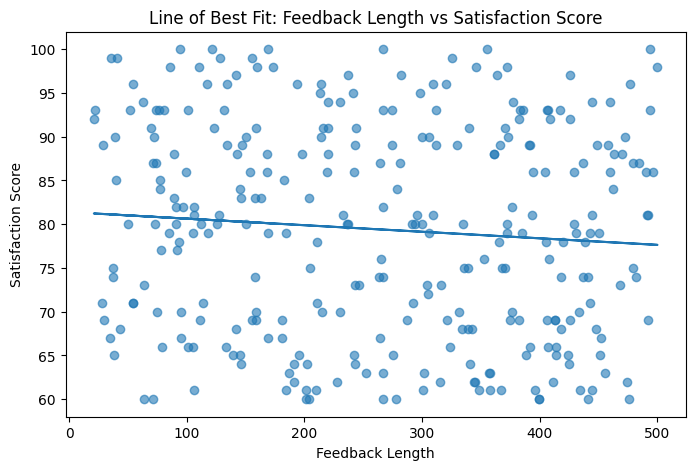

In [17]:
# Block 5 — Regression model

# Import the LinearRegression class from scikit-learn
# This is used to build a linear regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics for measuring model performance
# mean_absolute_error calculates the average absolute prediction error
# mean_squared_error calculates the average squared prediction error
# r2_score measures how well the model explains the variation in the outcome
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import numpy for numerical calculations
# Here it is used to calculate the square root when computing RMSE
import numpy as np

# Define the independent variables (predictors)
# These are the variables the model will use to predict Satisfaction Score
# Feedback Length is a numeric variable
# Issue Resolved Flag is a binary numeric variable created earlier
X = df[['Feedback Length', 'Issue Resolved Flag']]

# Define the dependent variable (outcome)
# This is the variable we are trying to predict
y = df['Satisfaction Score']

# Create the regression model
# LinearRegression() sets up a multiple linear regression object
reg_model = LinearRegression()

# Fit the model to the data
# This means the model learns the relationship between X and y
reg_model.fit(X, y)

# Use the fitted model to generate predicted values of Satisfaction Score
# based on the predictor variables in X
predictions = reg_model.predict(X)

# Print the intercept of the regression model
# The intercept is the predicted Satisfaction Score when all predictors equal zero
print('Intercept:', reg_model.intercept_)

# Print the coefficients for each predictor variable
# zip(X.columns, reg_model.coef_) pairs each column name with its coefficient
# dict() converts the result into a dictionary for easier reading
print('Coefficients:', dict(zip(X.columns, reg_model.coef_)))

# Print the R-squared value
# R-squared shows the proportion of variation in Satisfaction Score
# explained by the regression model
print('R-squared:', r2_score(y, predictions))

# Print the Mean Absolute Error (MAE)
# MAE tells us the average size of the prediction errors
# without considering whether they are positive or negative
print('MAE:', mean_absolute_error(y, predictions))

# Print the Root Mean Squared Error (RMSE)
# RMSE is another prediction error measure
# It penalizes larger errors more heavily than MAE
print('RMSE:', np.sqrt(mean_squared_error(y, predictions)))

# Block 5A — Scatterplot with line of best fit

import matplotlib.pyplot as plt
import numpy as np

# define x and y for the visual
x = df['Feedback Length']
y = df['Satisfaction Score']

# fit a simple line of best fit
m, b = np.polyfit(x, y, 1)

# create scatterplot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6)

# plot line of best fit
plt.plot(x, m * x + b)

# add chart labels and title
plt.xlabel('Feedback Length')
plt.ylabel('Satisfaction Score')
plt.title('Line of Best Fit: Feedback Length vs Satisfaction Score')

# show plot
plt.show()

## **Block 6A: Plot the Time Series, Moving Average, and Forecast**

**Purpose**

The purpose of this code is to visually display the actual monthly satisfaction scores, the 3-period moving average, and the forecasted next-month value. A graph helps students see the trend more clearly than a table alone and makes it easier to compare the actual data to the smoothed moving average line.

**Methodology**

This code uses `matplotlib` to create a line chart. One line shows the actual monthly average satisfaction scores, and another line shows the 3-period moving average. Then, one additional point is plotted to represent the next-month forecast based on the average of the last three observations. This gives students a clear visual of both historical performance and the projected future value.

**Plotting methods used**

* **Line plot for actual values**: Shows how satisfaction changes over time.
* **Line plot for 3-period moving average**: Shows the smoothed pattern in the data.
* **Forecast point**: Adds the predicted next month’s value to the chart.
* **Chart labels and title**: Make the graph easy to read and interpret.
* **Legend**: Distinguishes the actual line, moving average line, and forecast.

## Simple explanation for students

This code creates a chart that shows three things: the actual monthly satisfaction scores, the smoothed moving average trend, and the forecasted value for the next month. It helps students see how satisfaction changes over time and how the moving average can be used to make short-term predictions.

Here is an optional second plot if you want students to compare the actual values and moving average more cleanly.

## Block 6B: Plot Actual Values vs. Moving Average Only

**Purpose**
This version focuses only on the comparison between the real monthly values and the moving average, without adding the forecast point.


Time-series moving average results
          Date  Satisfaction Score       MA_3
295 2046-08-31                79.0  74.000000
296 2046-09-30                99.0  85.666667
297 2046-10-31                90.0  89.333333
298 2046-11-30                83.0  90.666667
299 2046-12-31                98.0  90.333333
Moving Average MAE: 7.82102908277405
Moving Average RMSE: 9.535756329184117
Next-month forecast: 90.33333333333333


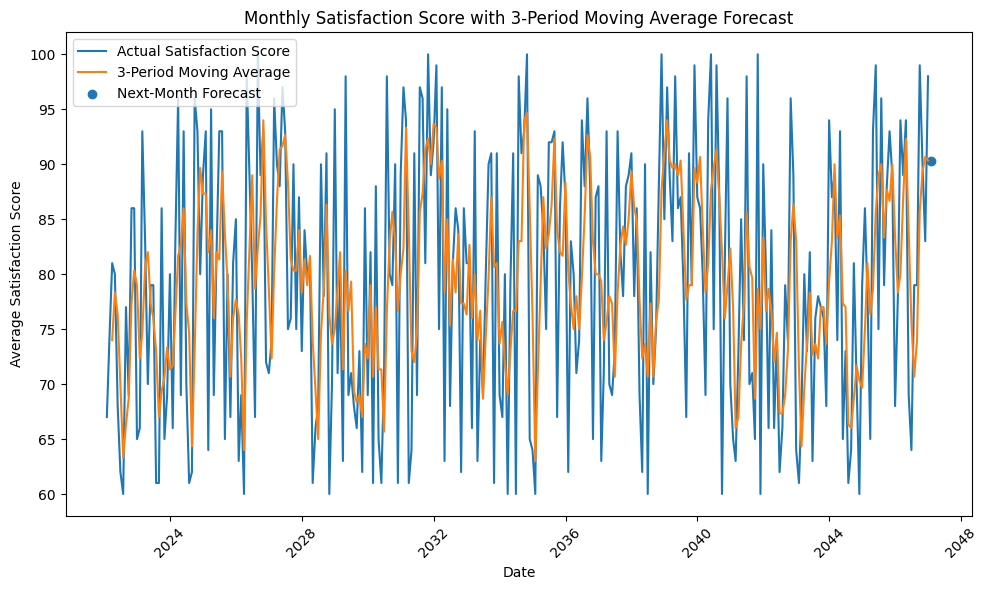

In [21]:
# ----------------------------
# Block 6 — Time-series moving average model
# ----------------------------

# Create a time-series summary table by date
monthly_summary = df.groupby('Date', as_index=False)['Satisfaction Score'].mean().sort_values('Date')

# Create a 3-period moving average
monthly_summary['MA_3'] = monthly_summary['Satisfaction Score'].rolling(3).mean()

# Keep only rows with valid moving-average values
valid_ts = monthly_summary.dropna()

# Calculate time-series error metrics
mae_ts = mean_absolute_error(valid_ts['Satisfaction Score'], valid_ts['MA_3'])
rmse_ts = np.sqrt(mean_squared_error(valid_ts['Satisfaction Score'], valid_ts['MA_3']))

# Forecast next period using the last 3 actual values
next_forecast = monthly_summary['Satisfaction Score'].tail(3).mean()

# Print time-series results
print("\nTime-series moving average results")
print(monthly_summary.tail())
print("Moving Average MAE:", mae_ts)
print("Moving Average RMSE:", rmse_ts)
print("Next-month forecast:", next_forecast)


# ----------------------------
# Block 6A — Plot the time series, moving average, and forecast
# ----------------------------

# Create figure
plt.figure(figsize=(10, 6))

# Plot actual monthly average satisfaction scores
plt.plot(monthly_summary['Date'], monthly_summary['Satisfaction Score'], label='Actual Satisfaction Score')

# Plot 3-period moving average
plt.plot(monthly_summary['Date'], monthly_summary['MA_3'], label='3-Period Moving Average')

# Create next forecast date
next_date = monthly_summary['Date'].max() + pd.DateOffset(months=1)

# Plot forecast point
plt.scatter(next_date, next_forecast, label='Next-Month Forecast')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Average Satisfaction Score')
plt.title('Monthly Satisfaction Score with 3-Period Moving Average Forecast')

# Add legend
plt.legend()

# Rotate dates for readability
plt.xticks(rotation=45)

# Adjust spacing
plt.tight_layout()
plt.show()

## **Block 7: Compare Regression and Time-Series Model Performance**

**Purpose**

The purpose of this code is to compare the predictive performance of the regression model and the time-series moving average model. Since both models generate estimates, this step helps determine which one provides more reliable predictions for the dataset. Comparing models is important because it supports better decision-making and helps students justify why one approach may be more useful than another.

**Methodology**

This code calculates the Root Mean Squared Error (RMSE) for the regression model and compares it to the RMSE already calculated for the time-series moving average model. RMSE is a common evaluation metric that measures the average size of prediction errors, with larger errors receiving more weight. After printing both RMSE values, the code uses an `if` statement to identify which model has the lower RMSE. The model with the lower RMSE is interpreted as the more reliable model for prediction in this dataset.

**Model comparison methods used**

* **Regression RMSE**: Measures the prediction error of the regression model.
* **Time-series RMSE**: Measures the prediction error of the moving average model.
* **Direct model comparison**: Compares the RMSE values from both models.
* **Conditional decision rule**: Uses an `if` statement to determine which model is more reliable based on the smaller RMSE.

**Simple explanation for students**

This code compares the regression model and the time-series model to see which one predicts more accurately. It does this by looking at RMSE for both models. The model with the lower RMSE is considered better because it has smaller prediction errors.


In [22]:
# ----------------------------
# Block 7 — Compare regression and time-series model performance
# ----------------------------

# Calculate the Root Mean Squared Error (RMSE) for the regression model
# This measures the average size of the regression model's prediction errors
# The lower the RMSE, the better the model fits the data
regression_rmse = np.sqrt(mean_squared_error(df['Satisfaction Score'], predictions))

# Print a heading for the comparison results
print("\nModel comparison")

# Print the regression model RMSE
# This tells us how much prediction error exists in the regression model
print("Regression RMSE:", regression_rmse)

# Print the time-series model RMSE
# rmse_ts was calculated earlier in Block 6 using the moving average model
print("Time-Series RMSE:", rmse_ts)

# Compare the two RMSE values
# The model with the smaller RMSE is considered more reliable
if rmse_ts < regression_rmse:
    print("The moving average model is more reliable for short-term forecasting in this dataset.")
else:
    print("The regression model is more reliable for this dataset.")


Model comparison
Regression RMSE: 11.822259336902937
Time-Series RMSE: 9.535756329184117
The moving average model is more reliable for short-term forecasting in this dataset.


## **Block 8: Export Tables for Reporting and Dashboard Use**

**Purpose**
The purpose of this code is to save important analysis results as separate CSV files so they can be used in reports, dashboards, presentations, or Power BI. Instead of keeping the results only inside Python, this step exports the summary tables into files that can be opened, shared, and reused in other applications.

**Methodology**
This code takes the DataFrames created in earlier analysis blocks and writes each one to a CSV file using the `.to_csv()` function. The `summary_stats` table is exported to store descriptive statistics, the `region_summary` table is exported to support regional comparisons, and the `monthly_summary` table is exported for time-series reporting and dashboard visuals. The final `print()` statement confirms that the export process has been completed successfully.

**Export methods used**

* **CSV export for `summary_stats`**: Saves descriptive statistics for use in reports or supporting documentation.
* **CSV export for `region_summary`**: Saves grouped regional results for comparisons, charts, or dashboards.
* **CSV export for `monthly_summary`**: Saves time-series results for trend analysis, forecasting visuals, or dashboard reporting.
* **`index=False` for time-series export**: Prevents pandas from saving row numbers as an extra column, which keeps the file cleaner and easier to use.


**Simple explanation for students**
This code saves the results from earlier analysis steps into separate CSV files. That makes it easier to use the outputs in Excel, Power BI, dashboards, reports, or presentations without having to rerun the analysis every time.


In [23]:
# ----------------------------
# Block 8 — Export tables for reporting / dashboard use
# ----------------------------

# Export the summary statistics table to a CSV file
# This file will contain results such as mean, median, and variance
# for the variables analyzed earlier
summary_stats.to_csv('group1_summary_stats.csv')

# Export the regional summary table to a CSV file
# This file stores the average values by region, which can be used
# for regional comparisons, charts, and dashboards
region_summary.to_csv('group1_region_summary.csv')

# Export the time-series summary table to a CSV file
# This file contains the date-based satisfaction data and moving average results
# index=False prevents pandas from adding row numbers as an extra column
monthly_summary.to_csv('group1_monthly_timeseries.csv', index=False)

# Print a confirmation message after all files are saved
print("\nExport complete: CSV files saved.")


Export complete: CSV files saved.
